# Exploração dos Dados Processados

Notebook utilizado para exploração dos dados processados com foco na correlação entre as _features_ e as variáveis _target_

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = '../../../data/processed'

In [2]:
# Bases processadas por fase, participante e condição
df_eda_p1 = pd.read_csv(f'{DATA_PATH}/eda_normalizado_p1v4.csv')
df_eda_p2 = pd.read_csv(f'{DATA_PATH}/eda_normalizado_p2v4.csv')
df_ppg_p1 = pd.read_csv(f'{DATA_PATH}/ppg_p1_v4.csv')
df_ppg_p2 = pd.read_csv(f'{DATA_PATH}/ppg_p2_v4.csv')

# Bases processadas por fase e janelas de 40s
df_pi2905_sawyer = pd.read_excel(f'{DATA_PATH}/PI-2905/40s_overlap50_Sawyer_agg_order.xlsx')
df_pi2905_ur10 = pd.read_excel(f'{DATA_PATH}/PI-2905/40s_overlap50_UR10_agg_order.xlsx')

In [3]:
print(f"Shape dos datasets")
print(f"df_eda_p1: {df_eda_p1.shape}")
print(f"df_ppg_p1: {df_ppg_p1.shape}")
print(f"df_eda_p2: {df_eda_p2.shape}")
print(f"df_ppg_p2: {df_ppg_p2.shape}")
print(f"df_pi2905_sawyer: {df_pi2905_sawyer.shape}")
print(f"df_pi2905_ur10: {df_pi2905_ur10.shape}")

Shape dos datasets
df_eda_p1: (144, 44)
df_ppg_p1: (144, 40)
df_eda_p2: (336, 44)
df_ppg_p2: (336, 40)
df_pi2905_sawyer: (142, 40)
df_pi2905_ur10: (368, 51)


# Processed by us

## Phase 1

In [4]:
keep = ['participant', 'condition', 'errors', 'secondary_task',
        'SCR_Onsets', 'SCR_Peaks', 'SCR_Recovery',
        'EDA_Clean_min', 'EDA_Clean_max','EDA_Clean_median','EDA_Clean_mean','EDA_Clean_std',
        'EDA_Tonic_min', 'EDA_Tonic_max','EDA_Tonic_median','EDA_Tonic_mean','EDA_Tonic_std',
        'EDA_Phasic_min', 'EDA_Phasic_max','EDA_Phasic_median','EDA_Phasic_mean','EDA_Phasic_std',
        'SCR_Height_min','SCR_Height_max','SCR_Height_median','SCR_Height_mean','SCR_Height_std',
        'SCR_Amplitude_min', 'SCR_Amplitude_max','SCR_Amplitude_median','SCR_Amplitude_mean','SCR_Amplitude_std',
        'SCR_RiseTime_min', 'SCR_RiseTime_max','SCR_RiseTime_median','SCR_RiseTime_mean','SCR_RiseTime_std',
        'SCR_RecoveryTime_min','SCR_RecoveryTime_max','SCR_RecoveryTime_median','SCR_RecoveryTime_mean','SCR_RecoveryTime_std'
]
df_eda_p1 = df_eda_p1[keep]

In [5]:
keep = [
        'participant', 'condition', 'secondary_task',
        'PPG_Rate_min', 'PPG_Rate_max', 'PPG_Rate_median', 'PPG_Rate_mean', 'PPG_Rate_std',
        'PPG_Quality_min', 'PPG_Quality_max', 'PPG_Quality_median', 'PPG_Quality_mean', 'PPG_Quality_std',
        'HRV_MeanNN_min', 'HRV_MeanNN_max', 'HRV_MeanNN_median', 'HRV_MeanNN_mean', 'HRV_MeanNN_std',
        'HRV_MedianNN_min', 'HRV_MedianNN_max', 'HRV_MedianNN_median', 'HRV_MedianNN_mean', 'HRV_MedianNN_std',
        'HRV_SDNN_min', 'HRV_SDNN_max', 'HRV_SDNN_median', 'HRV_SDNN_mean', 'HRV_SDNN_std',
        'HRV_RMSSD_min', 'HRV_RMSSD_max', 'HRV_RMSSD_median', 'HRV_RMSSD_mean', 'HRV_RMSSD_std',
        'HRV_pNN50_min', 'HRV_pNN50_max', 'HRV_pNN50_median', 'HRV_pNN50_mean', 'HRV_pNN50_std',
]
df_ppg_p1 = df_ppg_p1[keep]

In [6]:
df_p1 = pd.merge(left = df_eda_p1, right = df_ppg_p1, how="inner", on=["participant", "condition", "secondary_task"])
df_p1

,participant,condition,errors,secondary_task,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,...,HRV_RMSSD_min,HRV_RMSSD_max,HRV_RMSSD_median,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std
0,S06,V1P1,8.0,yes,8,8,6,0.338062,1.000000,0.806455,...,0.226361,0.226361,0.226361,0.226361,0.0,0.704788,0.704788,0.704788,0.704788,0.0
1,S06,V1P2,8.0,yes,6,6,5,0.080013,0.676468,0.273487,...,1.455505,1.455505,1.455505,1.455505,0.0,1.169811,1.169811,1.169811,1.169811,0.0
2,S06,V2P1,12.0,yes,4,4,3,0.324128,0.638592,0.438432,...,-0.327474,-0.327474,-0.327474,-0.327474,0.0,-0.341020,-0.341020,-0.341020,-0.341020,0.0
3,S06,V2P2,12.0,yes,16,16,16,0.080709,0.756460,0.442629,...,-0.308185,-0.308185,-0.308185,-0.308185,0.0,-0.466697,-0.466697,-0.466697,-0.466697,0.0
4,S06,V3P1,19.0,yes,16,15,14,0.000000,0.733756,0.364357,...,-0.141171,-0.141171,-0.141171,-0.141171,0.0,-0.143977,-0.143977,-0.143977,-0.143977,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,S30,V1P2,1.0,yes,6,6,6,0.528662,0.648691,0.585427,...,0.150984,0.150984,0.150984,0.150984,0.0,-0.135482,-0.135482,-0.135482,-0.135482,0.0
140,S30,V2P1,8.0,yes,3,3,2,0.583232,0.791924,0.714299,...,0.465390,0.465390,0.465390,0.465390,0.0,-0.145948,-0.145948,-0.145948,-0.145948,0.0
141,S30,V2P2,8.0,yes,0,1,0,0.000000,0.162325,0.063215,...,0.113379,0.113379,0.113379,0.113379,0.0,0.126799,0.126799,0.126799,0.126799,0.0
142,S30,V3P1,14.0,yes,2,1,2,0.245864,0.535732,0.435592,...,0.352609,0.352609,0.352609,0.352609,0.0,-0.153004,-0.153004,-0.153004,-0.153004,0.0


In [7]:
df_p1['participant'].value_counts()

participant
S06    6
S07    6
S08    6
S09    6
S10    6
S11    6
S12    6
S13    6
S14    6
S15    6
S16    6
S17    6
S18    6
S20    6
S21    6
S22    6
S23    6
S24    6
S25    6
S26    6
S27    6
S28    6
S29    6
S30    6
Name: count, dtype: int64

## Phase 2

In [8]:
keep = ['participant', 'condition', 'errors', 'secondary_task',
        'SCR_Onsets', 'SCR_Peaks', 'SCR_Recovery',
        'EDA_Clean_min', 'EDA_Clean_max','EDA_Clean_median','EDA_Clean_mean','EDA_Clean_std',
        'EDA_Tonic_min', 'EDA_Tonic_max','EDA_Tonic_median','EDA_Tonic_mean','EDA_Tonic_std',
        'EDA_Phasic_min', 'EDA_Phasic_max','EDA_Phasic_median','EDA_Phasic_mean','EDA_Phasic_std',
        'SCR_Height_min','SCR_Height_max','SCR_Height_median','SCR_Height_mean','SCR_Height_std',
        'SCR_Amplitude_min', 'SCR_Amplitude_max','SCR_Amplitude_median','SCR_Amplitude_mean','SCR_Amplitude_std',
        'SCR_RiseTime_min', 'SCR_RiseTime_max','SCR_RiseTime_median','SCR_RiseTime_mean','SCR_RiseTime_std',
        'SCR_RecoveryTime_min','SCR_RecoveryTime_max','SCR_RecoveryTime_median','SCR_RecoveryTime_mean','SCR_RecoveryTime_std'
]
df_eda_p2 = df_eda_p2[keep]

In [9]:
keep = [
        'participant', 'condition', 'secondary_task',
        'PPG_Rate_min', 'PPG_Rate_max', 'PPG_Rate_median', 'PPG_Rate_mean', 'PPG_Rate_std',
        'PPG_Quality_min', 'PPG_Quality_max', 'PPG_Quality_median', 'PPG_Quality_mean', 'PPG_Quality_std',
        'HRV_MeanNN_min', 'HRV_MeanNN_max', 'HRV_MeanNN_median', 'HRV_MeanNN_mean', 'HRV_MeanNN_std',
        'HRV_MedianNN_min', 'HRV_MedianNN_max', 'HRV_MedianNN_median', 'HRV_MedianNN_mean', 'HRV_MedianNN_std',
        'HRV_SDNN_min', 'HRV_SDNN_max', 'HRV_SDNN_median', 'HRV_SDNN_mean', 'HRV_SDNN_std',
        'HRV_RMSSD_min', 'HRV_RMSSD_max', 'HRV_RMSSD_median', 'HRV_RMSSD_mean', 'HRV_RMSSD_std',
        'HRV_pNN50_min', 'HRV_pNN50_max', 'HRV_pNN50_median', 'HRV_pNN50_mean', 'HRV_pNN50_std',
]
df_ppg_p2 = df_ppg_p2[keep]

In [10]:
df_p2 = pd.merge(left = df_eda_p2, right = df_ppg_p2, how="inner", on=["participant", "condition", "secondary_task"])
df_p2

,participant,condition,errors,secondary_task,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,...,HRV_RMSSD_min,HRV_RMSSD_max,HRV_RMSSD_median,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std
0,S101,V1P1,0.0,no,7,6,6,0.000000,0.198471,0.049975,...,-0.156196,-0.156196,-0.156196,-0.156196,0.0,0.219453,0.219453,0.219453,0.219453,0.0
1,S101,V1P2,0.0,no,5,5,5,0.131863,0.442195,0.225508,...,-0.227770,-0.227770,-0.227770,-0.227770,0.0,-0.083724,-0.083724,-0.083724,-0.083724,0.0
2,S101,V2P1,0.0,no,7,7,7,0.272779,0.535087,0.333670,...,-0.074642,-0.074642,-0.074642,-0.074642,0.0,-0.259753,-0.259753,-0.259753,-0.259753,0.0
3,S101,V2P2,0.0,no,7,7,7,0.259947,0.487941,0.305592,...,0.089250,0.089250,0.089250,0.089250,0.0,-0.027599,-0.027599,-0.027599,-0.027599,0.0
4,S101,V3P1,1.0,no,5,6,6,0.089661,0.307132,0.139455,...,-0.277195,-0.277195,-0.277195,-0.277195,0.0,0.101405,0.101405,0.101405,0.101405,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,S134,V1P2,1.0,yes,0,0,0,0.000000,0.255954,0.181596,...,-0.082403,-0.082403,-0.082403,-0.082403,0.0,-0.207209,-0.207209,-0.207209,-0.207209,0.0
332,S134,V2P1,0.0,yes,0,0,1,0.224907,0.387195,0.279009,...,-0.460657,-0.460657,-0.460657,-0.460657,0.0,-0.575336,-0.575336,-0.575336,-0.575336,0.0
333,S134,V2P2,0.0,yes,9,9,8,0.137123,1.000000,0.244437,...,-0.359785,-0.359785,-0.359785,-0.359785,0.0,-0.604392,-0.604392,-0.604392,-0.604392,0.0
334,S134,V3P1,2.0,yes,1,1,1,0.100251,0.434110,0.249875,...,-0.670290,-0.670290,-0.670290,-0.670290,0.0,-0.648161,-0.648161,-0.648161,-0.648161,0.0


In [11]:
# Todos OK
df_p2['participant'].value_counts()

participant
S101    12
S102    12
S104    12
S105    12
S106    12
S107    12
S108    12
S109    12
S110    12
S111    12
S112    12
S113    12
S115    12
S117    12
S119    12
S120    12
S121    12
S122    12
S123    12
S124    12
S125    12
S128    12
S129    12
S130    12
S131    12
S132    12
S133    12
S134    12
Name: count, dtype: int64

## Complete dataset

In [12]:
df_complete = pd.concat([df_p1, df_p2])
df_complete.shape

(480, 77)

In [13]:
df_complete.head()

,participant,condition,errors,secondary_task,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,...,HRV_RMSSD_min,HRV_RMSSD_max,HRV_RMSSD_median,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std
0,S06,V1P1,8.0,yes,8,8,6,0.338062,1.000000,0.806455,...,0.226361,0.226361,0.226361,0.226361,0.0,0.704788,0.704788,0.704788,0.704788,0.0
1,S06,V1P2,8.0,yes,6,6,5,0.080013,0.676468,0.273487,...,1.455505,1.455505,1.455505,1.455505,0.0,1.169811,1.169811,1.169811,1.169811,0.0
2,S06,V2P1,12.0,yes,4,4,3,0.324128,0.638592,0.438432,...,-0.327474,-0.327474,-0.327474,-0.327474,0.0,-0.341020,-0.341020,-0.341020,-0.341020,0.0
3,S06,V2P2,12.0,yes,16,16,16,0.080709,0.756460,0.442629,...,-0.308185,-0.308185,-0.308185,-0.308185,0.0,-0.466697,-0.466697,-0.466697,-0.466697,0.0
4,S06,V3P1,19.0,yes,16,15,14,0.000000,0.733756,0.364357,...,-0.141171,-0.141171,-0.141171,-0.141171,0.0,-0.143977,-0.143977,-0.143977,-0.143977,0.0


In [14]:
df_complete.to_csv('eda_ppg_complete.csv', index=False)

## Analysis

In [15]:
df_complete['speed'] = df_complete['condition'].str[1:2]
df_complete['position'] = df_complete['condition'].str[3:]
df_complete['secondary_task_bin'] =  df_complete['secondary_task'].apply(lambda x: 1 if x == 'yes' else 0)
df_complete_clean = df_complete.drop(['secondary_task'], axis=1)
df_complete_clean.head()

,participant,condition,errors,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,EDA_Clean_mean,...,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std,speed,position,secondary_task_bin
0,S06,V1P1,8.0,8,8,6,0.338062,1.000000,0.806455,0.806036,...,0.226361,0.0,0.704788,0.704788,0.704788,0.704788,0.0,1,1,1
1,S06,V1P2,8.0,6,6,5,0.080013,0.676468,0.273487,0.339273,...,1.455505,0.0,1.169811,1.169811,1.169811,1.169811,0.0,1,2,1
2,S06,V2P1,12.0,4,4,3,0.324128,0.638592,0.438432,0.482882,...,-0.327474,0.0,-0.341020,-0.341020,-0.341020,-0.341020,0.0,2,1,1
3,S06,V2P2,12.0,16,16,16,0.080709,0.756460,0.442629,0.418993,...,-0.308185,0.0,-0.466697,-0.466697,-0.466697,-0.466697,0.0,2,2,1
4,S06,V3P1,19.0,16,15,14,0.000000,0.733756,0.364357,0.379536,...,-0.141171,0.0,-0.143977,-0.143977,-0.143977,-0.143977,0.0,3,1,1


In [16]:
df_complete_clean.shape

(480, 79)

In [17]:
df_complete_clean.describe()

,errors,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,EDA_Clean_mean,EDA_Clean_std,EDA_Tonic_min,...,HRV_RMSSD_max,HRV_RMSSD_median,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std,secondary_task_bin
count,480.000000,480.00000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,...,476.000000,476.000000,476.000000,480.0,476.000000,476.000000,476.000000,476.000000,480.0,480.000000
mean,1.872917,6.45000,6.535417,6.441667,0.342815,0.626544,0.458433,0.463241,0.057493,0.387335,...,4.864325,4.864325,4.864325,0.0,1.377718,1.377718,1.377718,1.377718,0.0,0.650000
std,3.659075,6.16692,6.173449,6.044782,0.243605,0.257349,0.237157,0.234295,0.039495,0.258845,...,32.993122,32.993122,32.993122,0.0,7.597183,7.597183,7.597183,7.597183,0.0,0.477467
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.034693,0.017564,0.022451,0.002259,0.000000,...,-0.870556,-0.870556,-0.870556,0.0,-0.968235,-0.968235,-0.968235,-0.968235,0.0,0.000000
25%,0.000000,2.00000,2.000000,2.000000,0.137893,0.434462,0.272836,0.284545,0.030691,0.171087,...,-0.203546,-0.203546,-0.203546,0.0,-0.191731,-0.191731,-0.191731,-0.191731,0.0,0.000000
50%,0.000000,5.00000,5.000000,5.000000,0.324624,0.637955,0.457067,0.467429,0.048506,0.388596,...,0.184286,0.184286,0.184286,0.0,0.108913,0.108913,0.108913,0.108913,0.0,1.000000
75%,2.000000,10.00000,10.000000,10.000000,0.522561,0.832079,0.642103,0.642294,0.072658,0.584746,...,0.703788,0.703788,0.703788,0.0,0.523683,0.523683,0.523683,0.523683,0.0,1.000000
max,21.000000,62.00000,61.000000,58.000000,0.925814,1.000000,0.964892,0.958303,0.321517,0.957100,...,383.446336,383.446336,383.446336,0.0,65.833333,65.833333,65.833333,65.833333,0.0,1.000000


### Missing Values

In [18]:
# Checking missing values
for col in df_complete_clean.columns:
    na_count = df_complete_clean[col].isna().sum()
    if na_count > 0:
        print(f'{col}: {na_count}')

SCR_Height_min: 18
SCR_Height_max: 18
SCR_Height_median: 18
SCR_Height_mean: 18
SCR_Height_std: 18
SCR_Amplitude_min: 18
SCR_Amplitude_max: 18
SCR_Amplitude_median: 18
SCR_Amplitude_mean: 18
SCR_Amplitude_std: 18
SCR_RiseTime_min: 18
SCR_RiseTime_max: 18
SCR_RiseTime_median: 18
SCR_RiseTime_mean: 18
SCR_RiseTime_std: 18
HRV_MeanNN_min: 4
HRV_MeanNN_max: 4
HRV_MeanNN_median: 4
HRV_MeanNN_mean: 4
HRV_MedianNN_min: 4
HRV_MedianNN_max: 4
HRV_MedianNN_median: 4
HRV_MedianNN_mean: 4
HRV_SDNN_min: 4
HRV_SDNN_max: 4
HRV_SDNN_median: 4
HRV_SDNN_mean: 4
HRV_RMSSD_min: 4
HRV_RMSSD_max: 4
HRV_RMSSD_median: 4
HRV_RMSSD_mean: 4
HRV_pNN50_min: 4
HRV_pNN50_max: 4
HRV_pNN50_median: 4
HRV_pNN50_mean: 4


In [19]:
# Medidas referentes ao SCR ficam nulas, quando não é detectada a componente "fásica" e dinâmica do sinal EDA. 
# Obs. SCR: são as flutuações rápidas e de curto prazo que ocorrem imediatamente após um estímulo específico.
# Preenchendo valores missing com 0
df_complete_clean[[col for col in df_complete_clean.columns if col[:3] == 'SCR']] = df_complete_clean[[col for col in df_complete_clean.columns if col[:3] == 'SCR']].fillna(0)
df_complete_clean[df_complete_clean['SCR_Height_min'].isna()][[col for col in df_complete_clean.columns if col[:3] == 'SCR']]

,SCR_Onsets,SCR_Peaks,SCR_Recovery,SCR_Height_min,SCR_Height_max,SCR_Height_median,SCR_Height_mean,SCR_Height_std,SCR_Amplitude_min,SCR_Amplitude_max,...,SCR_RiseTime_min,SCR_RiseTime_max,SCR_RiseTime_median,SCR_RiseTime_mean,SCR_RiseTime_std,SCR_RecoveryTime_min,SCR_RecoveryTime_max,SCR_RecoveryTime_median,SCR_RecoveryTime_mean,SCR_RecoveryTime_std


In [20]:
# A variabilidade da frequência cardíaca (HRV) baseada em PPG (fotopletismografia) mede a variação nos intervalos de tempo 
# entre cada batimento cardíaco usando sensores de luz
df_complete_clean[df_complete_clean['HRV_MeanNN_min'].isna()][[col for col in df_complete_clean.columns if col[:3] == 'HRV']]

,HRV_MeanNN_min,HRV_MeanNN_max,HRV_MeanNN_median,HRV_MeanNN_mean,HRV_MeanNN_std,HRV_MedianNN_min,HRV_MedianNN_max,HRV_MedianNN_median,HRV_MedianNN_mean,HRV_MedianNN_std,...,HRV_RMSSD_min,HRV_RMSSD_max,HRV_RMSSD_median,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std
108,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0
111,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0
147,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0
248,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0


### Correlação com variável target Condition

In [21]:
df_test = df_complete_clean.drop(['participant', 'position', 'speed'], axis = 1)
df_test.reset_index(inplace=True, drop=True)
df_test.head()

,condition,errors,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,EDA_Clean_mean,EDA_Clean_std,...,HRV_RMSSD_max,HRV_RMSSD_median,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std,secondary_task_bin
0,V1P1,8.0,8,8,6,0.338062,1.000000,0.806455,0.806036,0.064524,...,0.226361,0.226361,0.226361,0.0,0.704788,0.704788,0.704788,0.704788,0.0,1
1,V1P2,8.0,6,6,5,0.080013,0.676468,0.273487,0.339273,0.145679,...,1.455505,1.455505,1.455505,0.0,1.169811,1.169811,1.169811,1.169811,0.0,1
2,V2P1,12.0,4,4,3,0.324128,0.638592,0.438432,0.482882,0.072220,...,-0.327474,-0.327474,-0.327474,0.0,-0.341020,-0.341020,-0.341020,-0.341020,0.0,1
3,V2P2,12.0,16,16,16,0.080709,0.756460,0.442629,0.418993,0.119541,...,-0.308185,-0.308185,-0.308185,0.0,-0.466697,-0.466697,-0.466697,-0.466697,0.0,1
4,V3P1,19.0,16,15,14,0.000000,0.733756,0.364357,0.379536,0.143147,...,-0.141171,-0.141171,-0.141171,0.0,-0.143977,-0.143977,-0.143977,-0.143977,0.0,1


In [22]:
code = {
    'V1P1': 1,
    'V1P2': 2,
    'V2P1': 3,
    'V2P2': 4,
    'V3P1': 5,
    'V3P2': 6,
}
df_test['condition_code'] = df_test['condition'].apply(lambda x: code[x])

In [23]:
corr_pos = df_test.drop(['condition'], axis = 1).corr()['condition_code'][:]
corr_pos = corr_pos[abs(corr_pos) > 0.2]
corr_pos

errors            0.247128
condition_code    1.000000
Name: condition_code, dtype: float64

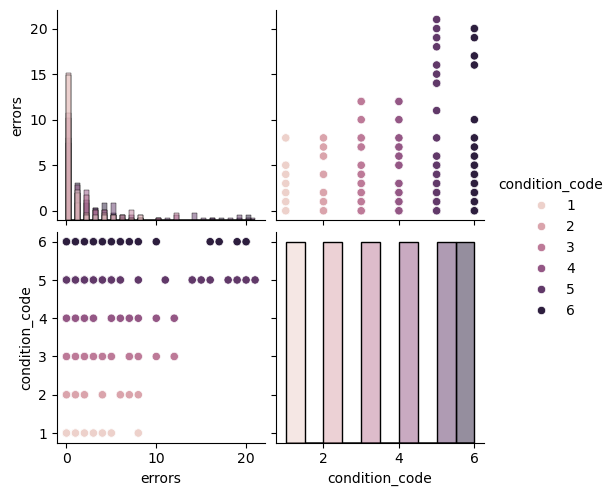

In [24]:
g = sns.pairplot(df_test[corr_pos.keys()], hue = 'condition_code', diag_kind= 'hist', vars=corr_pos.keys())
plt.show()

### Correlação com variável target Position

In [25]:
df_test = df_complete_clean.drop(['participant', 'condition'], axis = 1)
df_test.reset_index(inplace=True, drop=True)
df_test.head()

,errors,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,EDA_Clean_mean,EDA_Clean_std,EDA_Tonic_min,...,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std,speed,position,secondary_task_bin
0,8.0,8,8,6,0.338062,1.000000,0.806455,0.806036,0.064524,0.460069,...,0.226361,0.0,0.704788,0.704788,0.704788,0.704788,0.0,1,1,1
1,8.0,6,6,5,0.080013,0.676468,0.273487,0.339273,0.145679,0.034481,...,1.455505,0.0,1.169811,1.169811,1.169811,1.169811,0.0,1,2,1
2,12.0,4,4,3,0.324128,0.638592,0.438432,0.482882,0.072220,0.366935,...,-0.327474,0.0,-0.341020,-0.341020,-0.341020,-0.341020,0.0,2,1,1
3,12.0,16,16,16,0.080709,0.756460,0.442629,0.418993,0.119541,0.163901,...,-0.308185,0.0,-0.466697,-0.466697,-0.466697,-0.466697,0.0,2,2,1
4,19.0,16,15,14,0.000000,0.733756,0.364357,0.379536,0.143147,0.000000,...,-0.141171,0.0,-0.143977,-0.143977,-0.143977,-0.143977,0.0,3,1,1


In [26]:
corr_pos = df_test.corr()['position'][:]
corr_pos = corr_pos[abs(corr_pos) > 0.07]
corr_pos

position    1.0
Name: position, dtype: float64

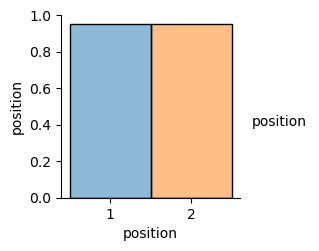

In [27]:
g = sns.pairplot(df_test[corr_pos.keys()], hue = 'position', diag_kind= 'hist', vars=corr_pos.keys())
plt.show()

### Correlação com variável target Speed

In [28]:
df_test = df_complete_clean.drop(['participant', 'condition'], axis = 1)
df_test.reset_index(inplace=True, drop=True)
df_test.head()

,errors,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,EDA_Clean_mean,EDA_Clean_std,EDA_Tonic_min,...,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std,speed,position,secondary_task_bin
0,8.0,8,8,6,0.338062,1.000000,0.806455,0.806036,0.064524,0.460069,...,0.226361,0.0,0.704788,0.704788,0.704788,0.704788,0.0,1,1,1
1,8.0,6,6,5,0.080013,0.676468,0.273487,0.339273,0.145679,0.034481,...,1.455505,0.0,1.169811,1.169811,1.169811,1.169811,0.0,1,2,1
2,12.0,4,4,3,0.324128,0.638592,0.438432,0.482882,0.072220,0.366935,...,-0.327474,0.0,-0.341020,-0.341020,-0.341020,-0.341020,0.0,2,1,1
3,12.0,16,16,16,0.080709,0.756460,0.442629,0.418993,0.119541,0.163901,...,-0.308185,0.0,-0.466697,-0.466697,-0.466697,-0.466697,0.0,2,2,1
4,19.0,16,15,14,0.000000,0.733756,0.364357,0.379536,0.143147,0.000000,...,-0.141171,0.0,-0.143977,-0.143977,-0.143977,-0.143977,0.0,3,1,1


In [29]:
corr_pos = df_test.corr()['speed'][:]
corr_pos = corr_pos[abs(corr_pos) > 0.17]
corr_pos

errors              0.277824
EDA_Clean_max       0.171815
EDA_Tonic_max       0.170665
EDA_Tonic_median    0.172085
speed               1.000000
Name: speed, dtype: float64

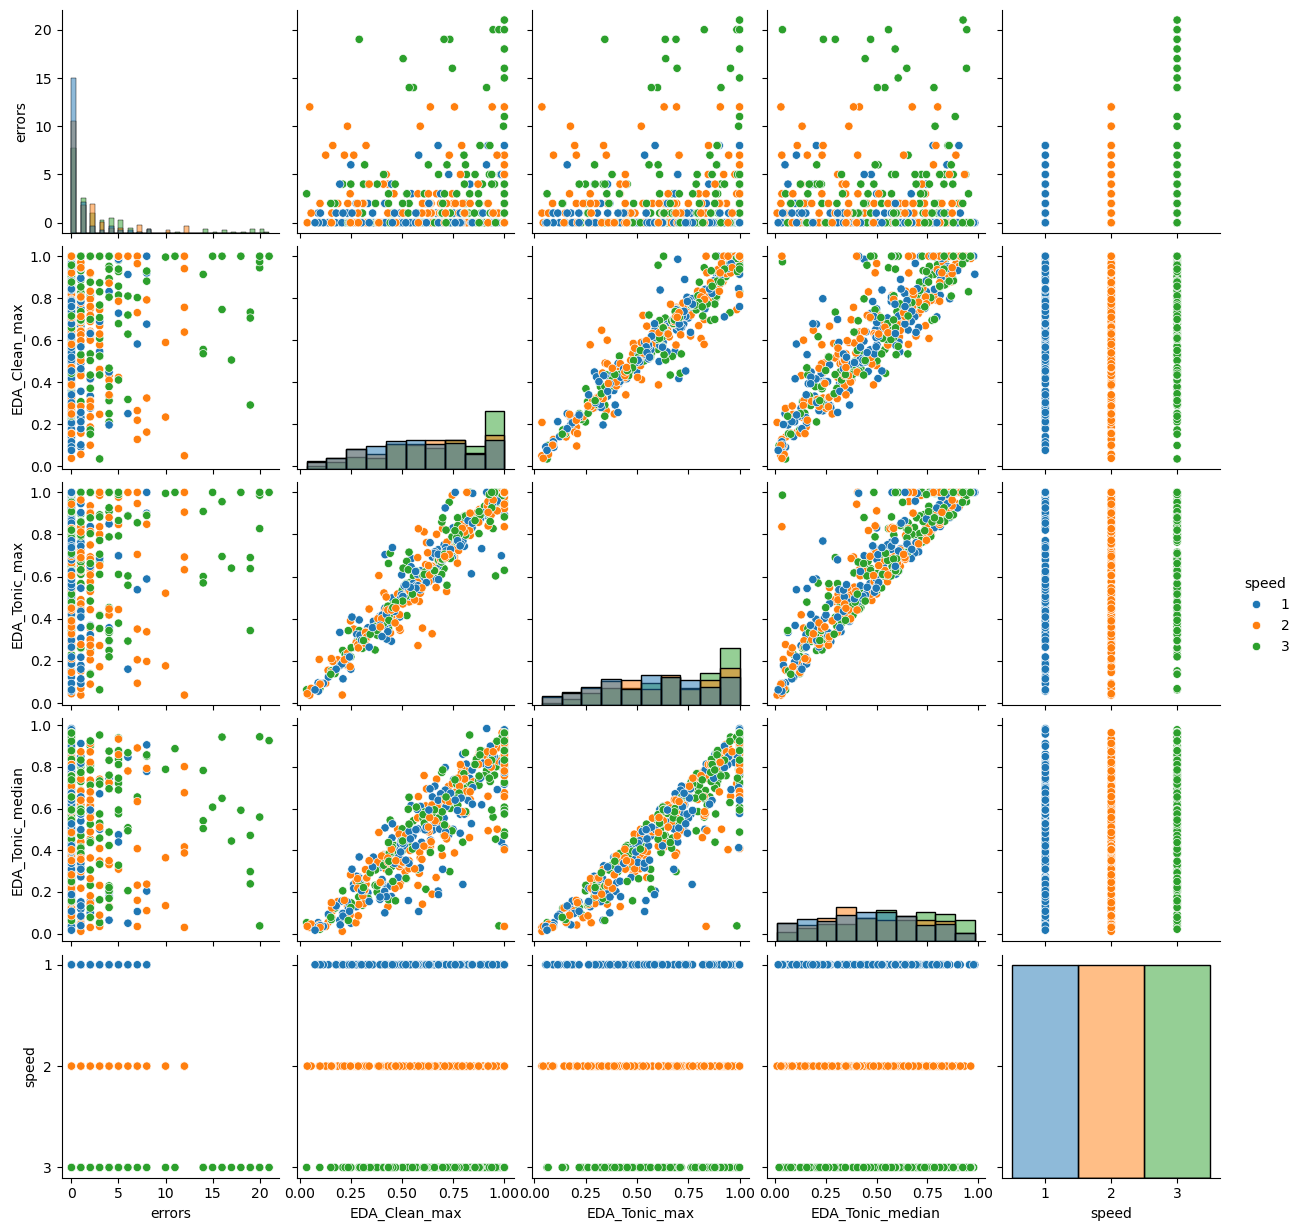

In [30]:
g = sns.pairplot(df_test[corr_pos.keys()], hue = 'speed', diag_kind= 'hist', vars=corr_pos.keys())
plt.show()

### Correlação com variável target Errors

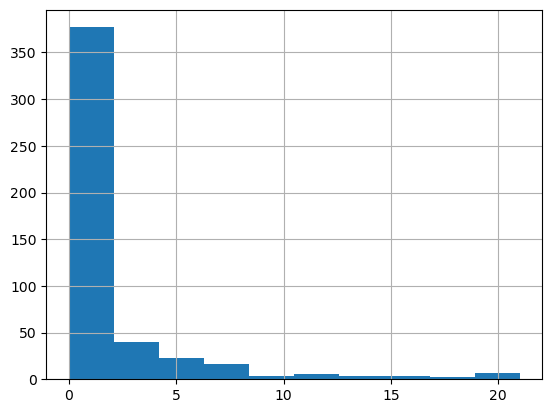

In [31]:
df_complete_clean['errors'].hist()
plt.show()

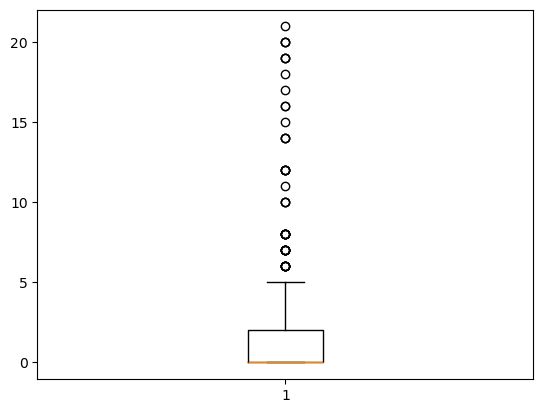

In [32]:
plt.boxplot(df_complete_clean['errors'])
plt.show()

In [33]:
df_test = df_complete_clean.drop(['participant', 'condition'], axis = 1)
df_test.reset_index(inplace=True, drop=True)
df_test.head()

,errors,SCR_Onsets,SCR_Peaks,SCR_Recovery,EDA_Clean_min,EDA_Clean_max,EDA_Clean_median,EDA_Clean_mean,EDA_Clean_std,EDA_Tonic_min,...,HRV_RMSSD_mean,HRV_RMSSD_std,HRV_pNN50_min,HRV_pNN50_max,HRV_pNN50_median,HRV_pNN50_mean,HRV_pNN50_std,speed,position,secondary_task_bin
0,8.0,8,8,6,0.338062,1.000000,0.806455,0.806036,0.064524,0.460069,...,0.226361,0.0,0.704788,0.704788,0.704788,0.704788,0.0,1,1,1
1,8.0,6,6,5,0.080013,0.676468,0.273487,0.339273,0.145679,0.034481,...,1.455505,0.0,1.169811,1.169811,1.169811,1.169811,0.0,1,2,1
2,12.0,4,4,3,0.324128,0.638592,0.438432,0.482882,0.072220,0.366935,...,-0.327474,0.0,-0.341020,-0.341020,-0.341020,-0.341020,0.0,2,1,1
3,12.0,16,16,16,0.080709,0.756460,0.442629,0.418993,0.119541,0.163901,...,-0.308185,0.0,-0.466697,-0.466697,-0.466697,-0.466697,0.0,2,2,1
4,19.0,16,15,14,0.000000,0.733756,0.364357,0.379536,0.143147,0.000000,...,-0.141171,0.0,-0.143977,-0.143977,-0.143977,-0.143977,0.0,3,1,1


In [34]:
corr_pos = df_test.corr()['errors'][:]
corr_pos = corr_pos[abs(corr_pos) > 0.15]
corr_pos

errors                1.000000
EDA_Clean_max         0.151066
EDA_Clean_std         0.235737
EDA_Tonic_std         0.204477
EDA_Phasic_max        0.166841
PPG_Quality_mean     -0.170356
speed                 0.277824
secondary_task_bin    0.323413
Name: errors, dtype: float64

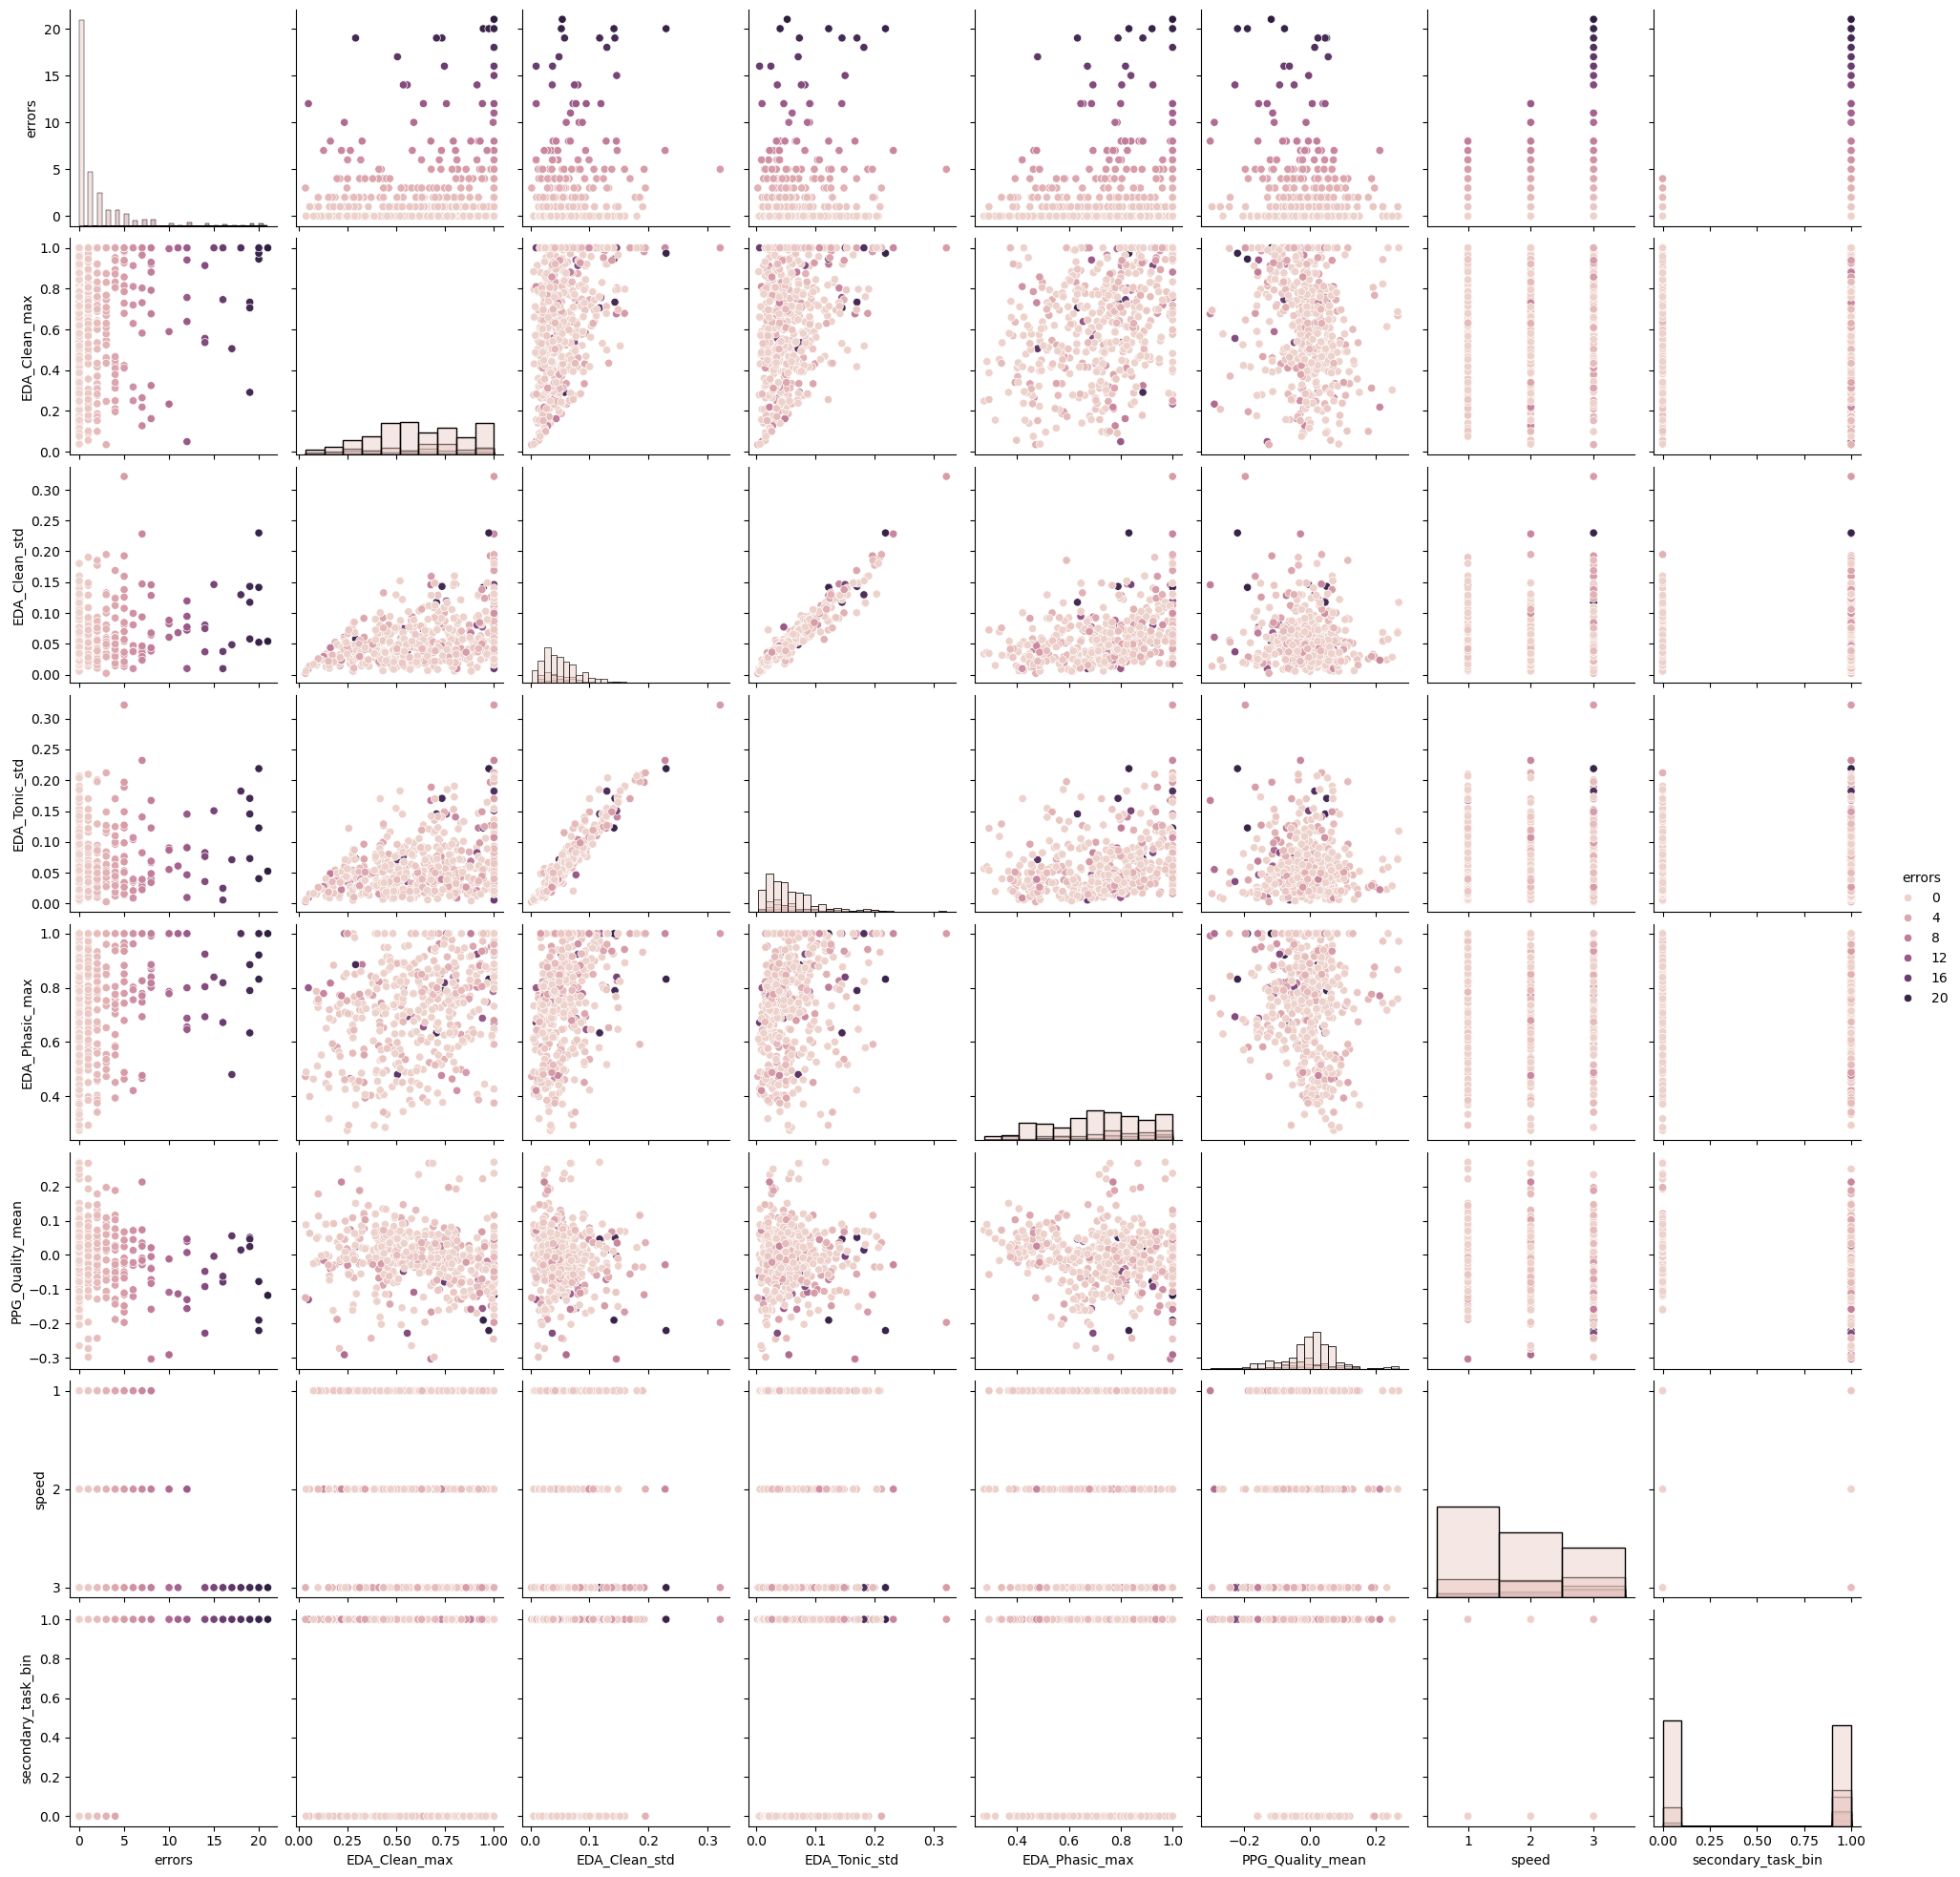

In [35]:
g = sns.pairplot(df_test[corr_pos.keys()], hue = 'errors', diag_kind= 'hist', vars=corr_pos.keys())
plt.show()

# Processed by Eduarda

In [36]:
df_pi2905_sawyer["Secondary_task"] = "yes"

In [37]:
df_pi2905_sawyer.columns.sort_values()

Index(['Code', 'Condition', 'EDA_HP_Phasic_AUC', 'EDA_HP_Phasic_Max',
       'EDA_HP_Phasic_Mean', 'EDA_HP_Phasic_nPeaks',
       'EDA_HP_SCR_Amplitude_Mean', 'EDA_HP_SCR_RiseTime', 'EDA_HP_Tonic_Mean',
       'EDA_HP_Tonic_Slope', 'EDA_SM_Phasic_AUC', 'EDA_SM_Phasic_Max',
       'EDA_SM_Phasic_Mean', 'EDA_SM_Phasic_nPeaks',
       'EDA_SM_SCR_Amplitude_Mean', 'EDA_SM_SCR_RiseTime', 'EDA_SM_Tonic_Mean',
       'EDA_SM_Tonic_Slope', 'EDA_cvx_Phasic_AUC', 'EDA_cvx_Phasic_Max',
       'EDA_cvx_Phasic_Mean', 'EDA_cvx_Phasic_nPeaks',
       'EDA_cvx_SCR_Amplitude_Mean', 'EDA_cvx_SCR_RiseTime',
       'EDA_cvx_Tonic_Mean', 'EDA_cvx_Tonic_Slope', 'HRV_LFHF', 'HR_BPM',
       'Order', 'Proximity', 'RMSSD', 'SDNN', 'Secondary_task', 'Speed',
       'Start_min', 'Subject', 'Temp_Mean', 'Temp_Slope', 'Temp_Std', 'pNN20',
       'pNN50'],
      dtype='str')

In [38]:
df_pi2905_ur10.columns.sort_values()

Index(['Code', 'Condition', 'EDA_HP_Phasic_AUC', 'EDA_HP_Phasic_Max',
       'EDA_HP_Phasic_Mean', 'EDA_HP_Phasic_nPeaks',
       'EDA_HP_SCR_Amplitude_Mean', 'EDA_HP_SCR_RiseTime', 'EDA_HP_Tonic_Mean',
       'EDA_HP_Tonic_Slope', 'EDA_SM_Phasic_AUC', 'EDA_SM_Phasic_Max',
       'EDA_SM_Phasic_Mean', 'EDA_SM_Phasic_nPeaks',
       'EDA_SM_SCR_Amplitude_Mean', 'EDA_SM_SCR_RiseTime', 'EDA_SM_Tonic_Mean',
       'EDA_SM_Tonic_Slope', 'EDA_cvx_Phasic_AUC', 'EDA_cvx_Phasic_Max',
       'EDA_cvx_Phasic_Mean', 'EDA_cvx_Phasic_nPeaks',
       'EDA_cvx_SCR_Amplitude_Mean', 'EDA_cvx_SCR_RiseTime',
       'EDA_cvx_Tonic_Mean', 'EDA_cvx_Tonic_Slope', 'HRV_HF', 'HRV_LF',
       'HRV_LFHF', 'HR_BPM', 'Order', 'PPG_Hjorth_Comp', 'PPG_Hjorth_Mob',
       'PPG_Perm_Entropy', 'PPG_SQI_mean', 'PPG_SQI_min', 'PPG_kurtosis',
       'PPG_n_peaks', 'PPG_skewness', 'Proximity', 'RMSSD', 'SDNN',
       'Secondary_task', 'Speed', 'Start_min', 'Subject', 'Temp_Mean',
       'Temp_Slope', 'Temp_Std', 'pNN20', 'p

In [39]:
drop_cols = ['HRV_HF', 'HRV_LF', 'PPG_Hjorth_Comp', 'PPG_Hjorth_Mob',
'PPG_Perm_Entropy', 'PPG_SQI_mean', 'PPG_SQI_min', 'PPG_kurtosis',
'PPG_n_peaks', 'PPG_skewness']

## Complete dataset

In [40]:
df_complete = pd.concat([df_pi2905_sawyer, df_pi2905_ur10.drop(drop_cols, axis = 1)])
df_complete.shape

(510, 41)

In [41]:
df_complete.head()

,Subject,Code,Condition,Speed,Proximity,Order,HR_BPM,RMSSD,SDNN,pNN50,...,EDA_SM_Phasic_Mean,EDA_SM_Phasic_AUC,EDA_SM_Phasic_nPeaks,EDA_SM_SCR_RiseTime,EDA_SM_SCR_Amplitude_Mean,Temp_Mean,Temp_Std,Temp_Slope,Start_min,Secondary_task
0,6,11,V3P1,V3,P1,2,82.987497,58.458733,50.941212,23.584906,...,0.005336,0.213363,19.0,0.559028,0.018879,-0.053254,0.002925,0.000252,3.532873,yes
1,6,10,V2P2,V2,P2,3,82.229231,39.076153,48.381044,13.843137,...,0.002298,0.091895,7.0,1.024740,0.031179,0.007511,0.001300,0.000112,8.003206,yes
2,6,12,V3P2,V3,P2,4,82.770386,60.234428,66.317346,20.936139,...,0.003109,0.124347,12.0,0.853232,0.014874,0.019901,0.000705,0.000036,13.794873,yes
3,6,9,V2P1,V2,P1,5,83.852901,73.823440,75.730977,25.471698,...,0.001642,0.065549,24.5,0.557639,0.005068,0.021971,0.000860,0.000073,18.492206,yes
4,6,7,V1P1,V1,P1,6,84.728307,149.464321,106.856818,60.784314,...,0.003249,0.129827,20.0,0.607422,0.007371,0.004370,0.001620,-0.000140,23.631206,yes


In [42]:
# Participante 11 tem as 6 condições nessa base
# Participantes 115 e 127 não tem dados raw disponibilizados, logo não estão na nossa versão da base de dados
subs = df_complete.Subject.value_counts()
subs[~subs.isin([6, 12])]

Subject
115    11
119    11
127    11
128    11
6       5
27      5
Name: count, dtype: int64

## Analysis

In [43]:
df_complete['speed'] = df_complete['Condition'].str[1:2]
df_complete['position'] = df_complete['Condition'].str[3:]
df_complete['secondary_task_bin'] =  df_complete['Secondary_task'].apply(lambda x: 1 if x == 'yes' else 0)
df_complete_clean = df_complete.drop(['Secondary_task', 'Condition', 'Speed', 'Proximity'], axis=1)
df_complete_clean.head()

,Subject,Code,Order,HR_BPM,RMSSD,SDNN,pNN50,pNN20,HRV_LFHF,EDA_cvx_Tonic_Mean,...,EDA_SM_Phasic_nPeaks,EDA_SM_SCR_RiseTime,EDA_SM_SCR_Amplitude_Mean,Temp_Mean,Temp_Std,Temp_Slope,Start_min,speed,position,secondary_task_bin
0,6,11,2,82.987497,58.458733,50.941212,23.584906,64.150943,0.198433,-0.128524,...,19.0,0.559028,0.018879,-0.053254,0.002925,0.000252,3.532873,3,1,1
1,6,10,3,82.229231,39.076153,48.381044,13.843137,60.188679,0.727641,0.078605,...,7.0,1.024740,0.031179,0.007511,0.001300,0.000112,8.003206,2,2,1
2,6,12,4,82.770386,60.234428,66.317346,20.936139,57.148041,0.222568,0.272838,...,12.0,0.853232,0.014874,0.019901,0.000705,0.000036,13.794873,3,2,1
3,6,9,5,83.852901,73.823440,75.730977,25.471698,63.176638,0.586882,0.289075,...,24.5,0.557639,0.005068,0.021971,0.000860,0.000073,18.492206,2,1,1
4,6,7,6,84.728307,149.464321,106.856818,60.784314,75.000000,0.277790,0.818610,...,20.0,0.607422,0.007371,0.004370,0.001620,-0.000140,23.631206,1,1,1


In [44]:
df_complete_clean.shape

(510, 40)

In [45]:
df_complete_clean.describe()

,Subject,Code,Order,HR_BPM,RMSSD,SDNN,pNN50,pNN20,HRV_LFHF,EDA_cvx_Tonic_Mean,...,EDA_SM_Phasic_Mean,EDA_SM_Phasic_AUC,EDA_SM_Phasic_nPeaks,EDA_SM_SCR_RiseTime,EDA_SM_SCR_Amplitude_Mean,Temp_Mean,Temp_Std,Temp_Slope,Start_min,secondary_task_bin
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,...,498.000000,498.000000,498.000000,498.000000,498.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,90.164706,7.325490,5.556863,80.830647,131.780472,110.576058,45.901937,72.104838,0.374571,0.662444,...,0.002210,0.088322,18.729920,1.013249,0.006576,-0.003943,0.000854,0.000012,19.542744,0.639216
std,45.835534,3.356947,3.296677,11.778426,105.061244,80.727728,25.414837,13.572940,0.303446,1.054109,...,0.002703,0.108037,12.993879,0.556009,0.008423,0.065618,0.001139,0.000099,12.691207,0.480700
min,6.000000,1.000000,1.000000,51.004525,24.169061,19.454146,1.408451,42.622951,0.028533,-1.611366,...,0.000021,0.000836,3.000000,0.255682,0.000059,-0.214622,0.000025,-0.000243,0.000000,0.000000
25%,28.000000,5.000000,3.000000,74.840148,48.254672,49.680234,23.934783,61.111111,0.190380,0.045634,...,0.000386,0.015370,10.000000,0.584003,0.000944,-0.020984,0.000304,-0.000045,9.457564,0.000000
50%,111.000000,8.000000,5.000000,80.261423,81.357696,78.246466,43.668955,70.588235,0.287822,0.328851,...,0.001175,0.046927,15.000000,0.851616,0.003281,-0.002939,0.000579,-0.000004,18.713855,1.000000
75%,124.000000,10.000000,8.000000,87.407068,200.123846,152.901695,69.230769,84.484266,0.456316,1.047413,...,0.003079,0.123147,23.875000,1.323597,0.008801,0.013299,0.000983,0.000047,29.331748,1.000000
max,134.000000,12.000000,12.000000,119.775561,442.981664,368.113437,95.454545,100.000000,2.578466,6.002534,...,0.016167,0.646382,77.000000,3.343750,0.060304,0.362911,0.012922,0.000594,51.392138,1.000000


### Missing Values

In [46]:
# Checking missing values
for col in df_complete_clean.columns:
    na_count = df_complete_clean[col].isna().sum()
    if na_count > 0:
        print(f'{col}: {na_count}')

EDA_cvx_Phasic_nPeaks: 12
EDA_cvx_SCR_RiseTime: 12
EDA_cvx_SCR_Amplitude_Mean: 12
EDA_HP_Tonic_Mean: 12
EDA_HP_Tonic_Slope: 12
EDA_HP_Phasic_Max: 12
EDA_HP_Phasic_Mean: 12
EDA_HP_Phasic_AUC: 12
EDA_HP_Phasic_nPeaks: 12
EDA_HP_SCR_RiseTime: 12
EDA_HP_SCR_Amplitude_Mean: 12
EDA_SM_Tonic_Mean: 12
EDA_SM_Tonic_Slope: 12
EDA_SM_Phasic_Max: 12
EDA_SM_Phasic_Mean: 12
EDA_SM_Phasic_AUC: 12
EDA_SM_Phasic_nPeaks: 12
EDA_SM_SCR_RiseTime: 12
EDA_SM_SCR_Amplitude_Mean: 12


### Correlação com variável target Condition

In [47]:
df_test = df_complete_clean.drop(['Subject', 'position', 'speed'], axis = 1)
df_test.reset_index(inplace=True, drop=True)
df_test.head()

,Code,Order,HR_BPM,RMSSD,SDNN,pNN50,pNN20,HRV_LFHF,EDA_cvx_Tonic_Mean,EDA_cvx_Tonic_Slope,...,EDA_SM_Phasic_Mean,EDA_SM_Phasic_AUC,EDA_SM_Phasic_nPeaks,EDA_SM_SCR_RiseTime,EDA_SM_SCR_Amplitude_Mean,Temp_Mean,Temp_Std,Temp_Slope,Start_min,secondary_task_bin
0,11,2,82.987497,58.458733,50.941212,23.584906,64.150943,0.198433,-0.128524,0.001834,...,0.005336,0.213363,19.0,0.559028,0.018879,-0.053254,0.002925,0.000252,3.532873,1
1,10,3,82.229231,39.076153,48.381044,13.843137,60.188679,0.727641,0.078605,0.004396,...,0.002298,0.091895,7.0,1.024740,0.031179,0.007511,0.001300,0.000112,8.003206,1
2,12,4,82.770386,60.234428,66.317346,20.936139,57.148041,0.222568,0.272838,0.003939,...,0.003109,0.124347,12.0,0.853232,0.014874,0.019901,0.000705,0.000036,13.794873,1
3,9,5,83.852901,73.823440,75.730977,25.471698,63.176638,0.586882,0.289075,0.003564,...,0.001642,0.065549,24.5,0.557639,0.005068,0.021971,0.000860,0.000073,18.492206,1
4,7,6,84.728307,149.464321,106.856818,60.784314,75.000000,0.277790,0.818610,0.001293,...,0.003249,0.129827,20.0,0.607422,0.007371,0.004370,0.001620,-0.000140,23.631206,1


In [48]:
corr_pos = df_test.corr()['Code'][:]
corr_pos = corr_pos[abs(corr_pos) > 0.2]
corr_pos

Code                     1.000000
RMSSD                    0.212493
SDNN                     0.203304
EDA_cvx_Phasic_nPeaks    0.297219
secondary_task_bin       0.860629
Name: Code, dtype: float64

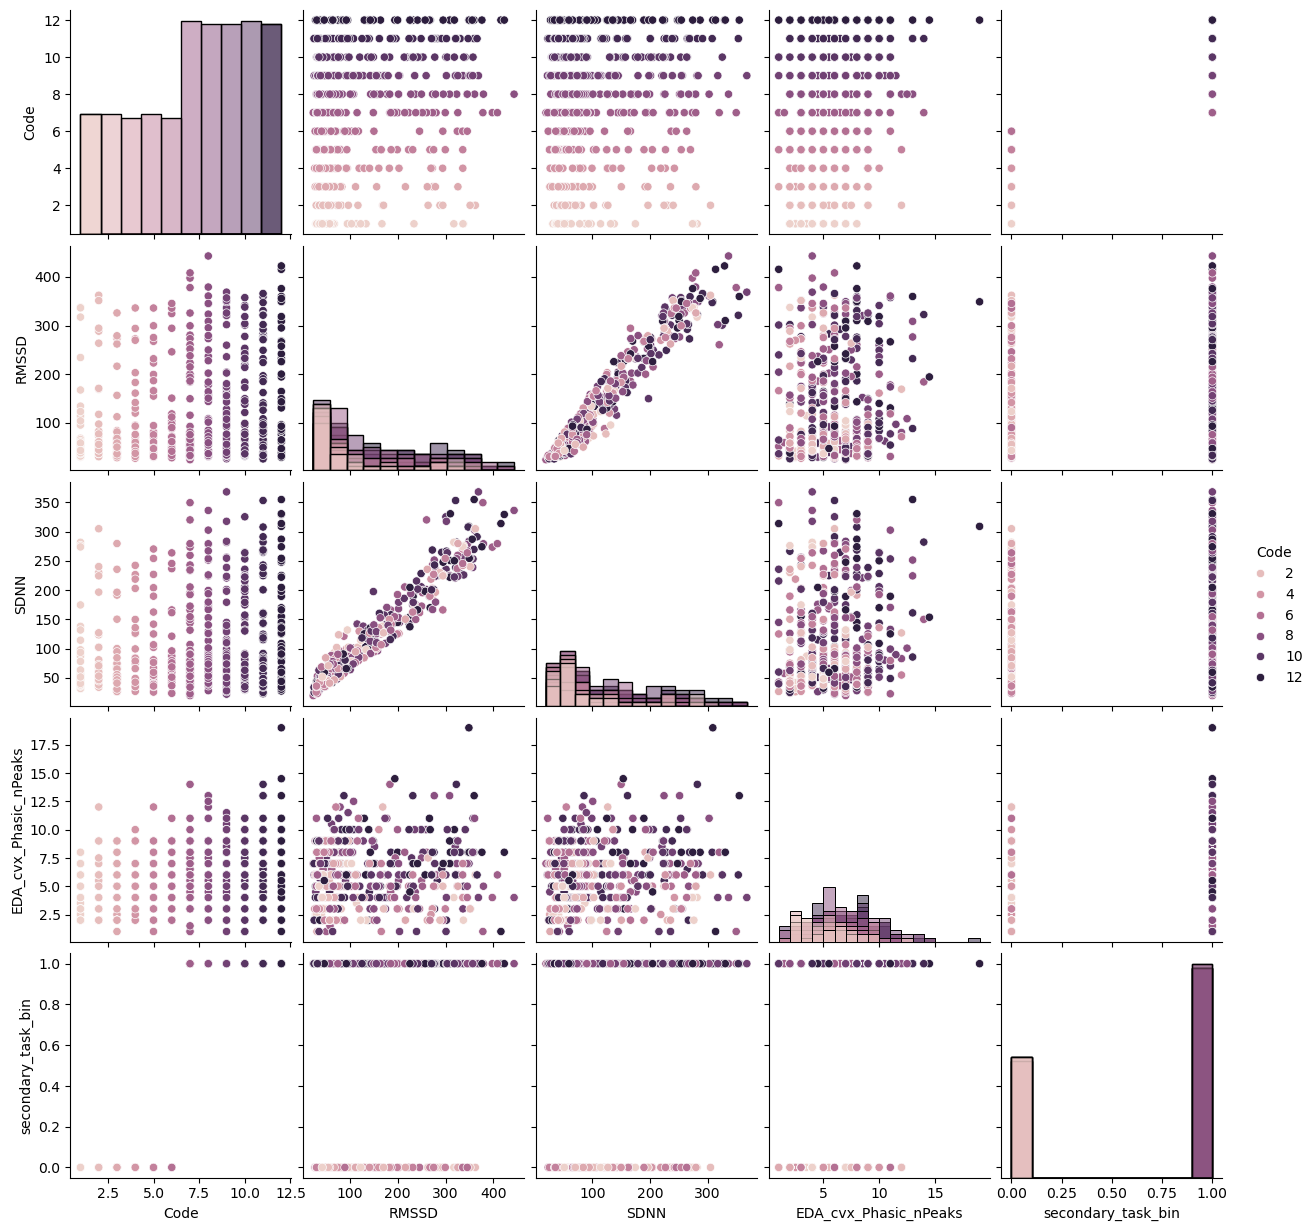

In [49]:
g = sns.pairplot(df_test[corr_pos.keys()], hue = 'Code', diag_kind= 'hist', vars=corr_pos.keys())
plt.show()

### Correlação com variável target Position

In [50]:
df_test = df_complete_clean.drop(['Subject', 'Code'], axis = 1)
df_test.reset_index(inplace=True, drop=True)
df_test.head()

,Order,HR_BPM,RMSSD,SDNN,pNN50,pNN20,HRV_LFHF,EDA_cvx_Tonic_Mean,EDA_cvx_Tonic_Slope,EDA_cvx_Phasic_Max,...,EDA_SM_Phasic_nPeaks,EDA_SM_SCR_RiseTime,EDA_SM_SCR_Amplitude_Mean,Temp_Mean,Temp_Std,Temp_Slope,Start_min,speed,position,secondary_task_bin
0,2,82.987497,58.458733,50.941212,23.584906,64.150943,0.198433,-0.128524,0.001834,1.165892,...,19.0,0.559028,0.018879,-0.053254,0.002925,0.000252,3.532873,3,1,1
1,3,82.229231,39.076153,48.381044,13.843137,60.188679,0.727641,0.078605,0.004396,-0.159979,...,7.0,1.024740,0.031179,0.007511,0.001300,0.000112,8.003206,2,2,1
2,4,82.770386,60.234428,66.317346,20.936139,57.148041,0.222568,0.272838,0.003939,0.233134,...,12.0,0.853232,0.014874,0.019901,0.000705,0.000036,13.794873,3,2,1
3,5,83.852901,73.823440,75.730977,25.471698,63.176638,0.586882,0.289075,0.003564,-0.325822,...,24.5,0.557639,0.005068,0.021971,0.000860,0.000073,18.492206,2,1,1
4,6,84.728307,149.464321,106.856818,60.784314,75.000000,0.277790,0.818610,0.001293,-0.628247,...,20.0,0.607422,0.007371,0.004370,0.001620,-0.000140,23.631206,1,1,1


In [51]:
corr_pos = df_test.corr()['position'][:]
corr_pos = corr_pos[abs(corr_pos) > 0.05]
corr_pos

HR_BPM                   0.052492
EDA_cvx_Tonic_Slope      0.125490
EDA_cvx_Phasic_nPeaks    0.052129
position                 1.000000
Name: position, dtype: float64

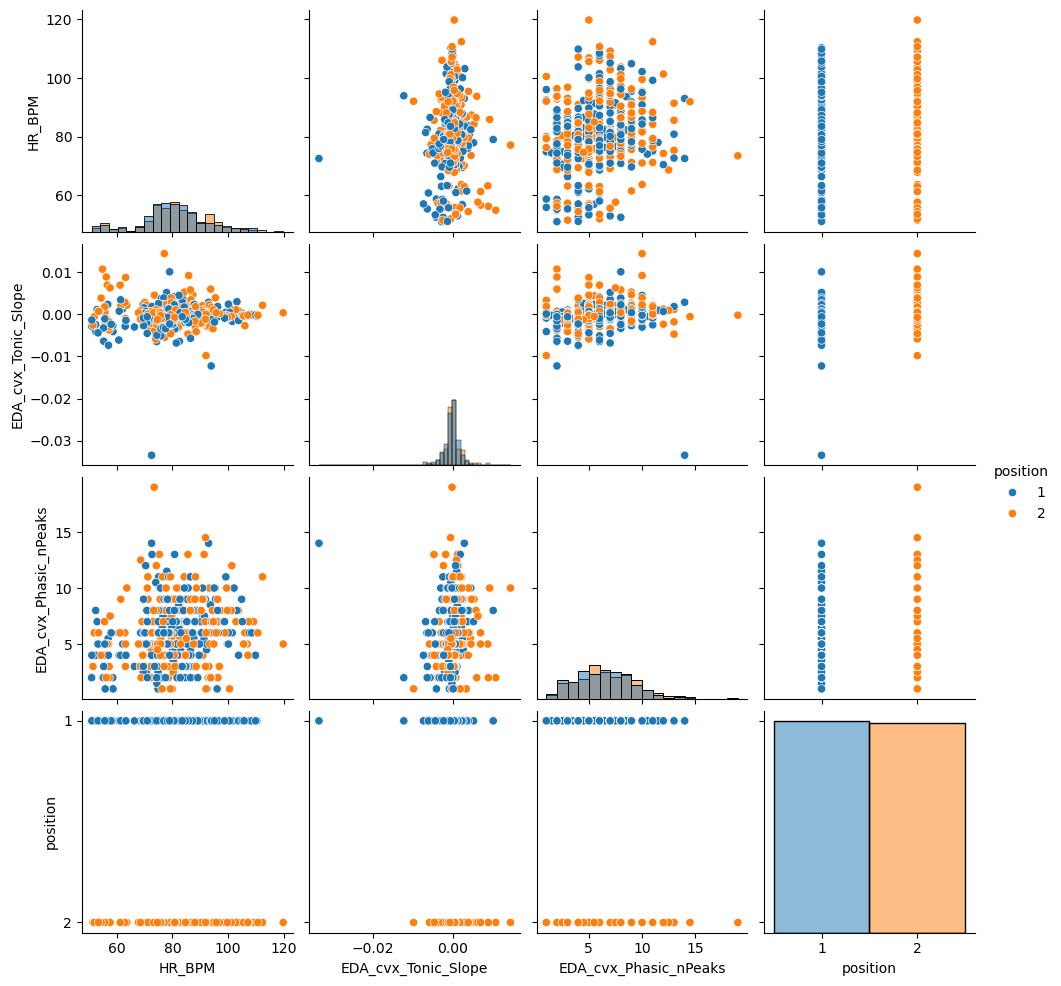

In [52]:
g = sns.pairplot(df_test[corr_pos.keys()], hue = 'position', diag_kind= 'hist', vars=corr_pos.keys())
plt.show()

### Correlação com variável target Speed

In [53]:
df_test = df_complete_clean.drop(['Subject', 'Code'], axis = 1)
df_test.reset_index(inplace=True, drop=True)
df_test.head()

,Order,HR_BPM,RMSSD,SDNN,pNN50,pNN20,HRV_LFHF,EDA_cvx_Tonic_Mean,EDA_cvx_Tonic_Slope,EDA_cvx_Phasic_Max,...,EDA_SM_Phasic_nPeaks,EDA_SM_SCR_RiseTime,EDA_SM_SCR_Amplitude_Mean,Temp_Mean,Temp_Std,Temp_Slope,Start_min,speed,position,secondary_task_bin
0,2,82.987497,58.458733,50.941212,23.584906,64.150943,0.198433,-0.128524,0.001834,1.165892,...,19.0,0.559028,0.018879,-0.053254,0.002925,0.000252,3.532873,3,1,1
1,3,82.229231,39.076153,48.381044,13.843137,60.188679,0.727641,0.078605,0.004396,-0.159979,...,7.0,1.024740,0.031179,0.007511,0.001300,0.000112,8.003206,2,2,1
2,4,82.770386,60.234428,66.317346,20.936139,57.148041,0.222568,0.272838,0.003939,0.233134,...,12.0,0.853232,0.014874,0.019901,0.000705,0.000036,13.794873,3,2,1
3,5,83.852901,73.823440,75.730977,25.471698,63.176638,0.586882,0.289075,0.003564,-0.325822,...,24.5,0.557639,0.005068,0.021971,0.000860,0.000073,18.492206,2,1,1
4,6,84.728307,149.464321,106.856818,60.784314,75.000000,0.277790,0.818610,0.001293,-0.628247,...,20.0,0.607422,0.007371,0.004370,0.001620,-0.000140,23.631206,1,1,1


In [54]:
corr_pos = df_test.corr()['speed'][:]
corr_pos = corr_pos[abs(corr_pos) > 0.1]
corr_pos

HRV_LFHF                    -0.138842
EDA_cvx_Phasic_nPeaks        0.138005
EDA_SM_Phasic_Mean           0.143007
EDA_SM_Phasic_AUC            0.142973
EDA_SM_SCR_Amplitude_Mean    0.106202
speed                        1.000000
Name: speed, dtype: float64

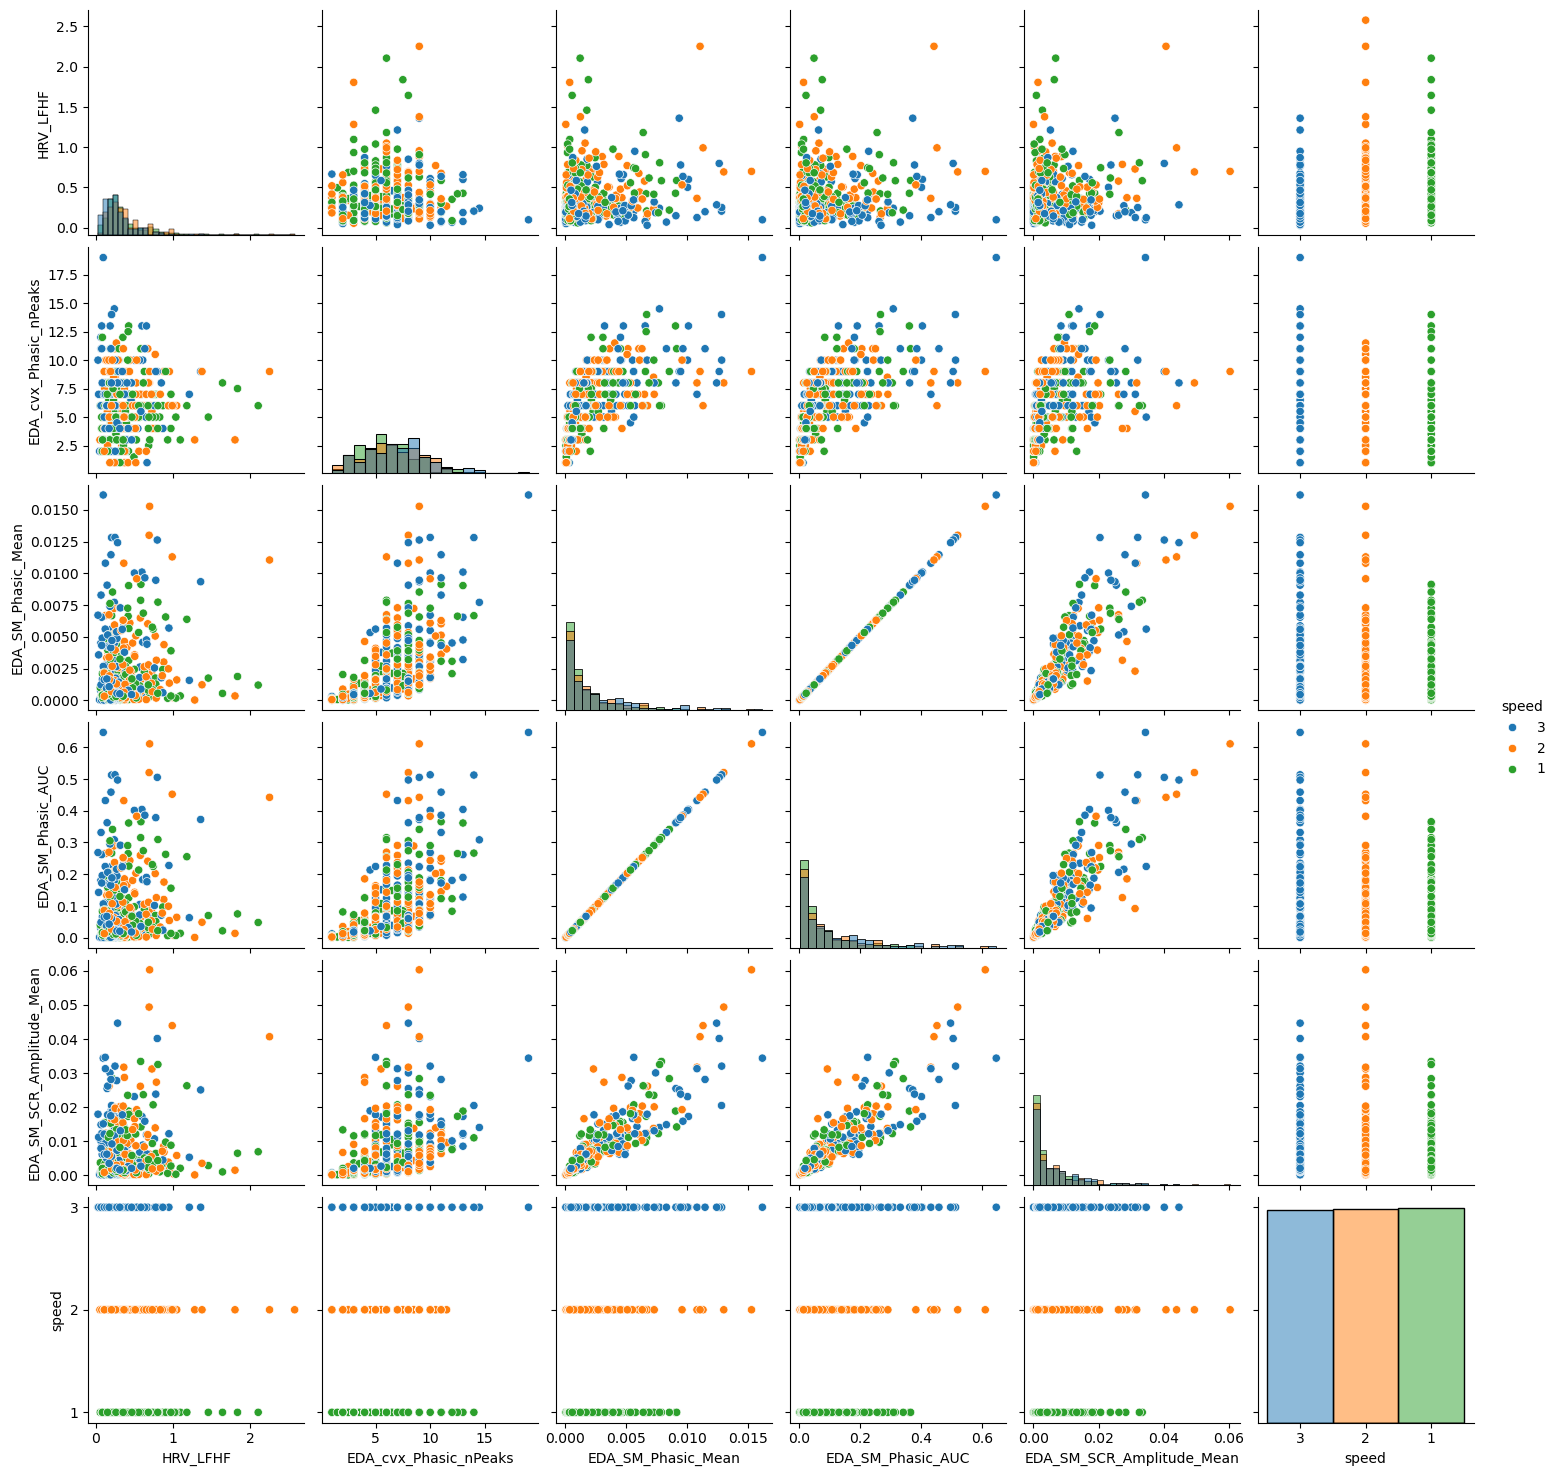

In [55]:
g = sns.pairplot(df_test[corr_pos.keys()], hue = 'speed', diag_kind= 'hist', vars=corr_pos.keys())
plt.show()